#### Importing Dependencies

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import joblib
base_dir = Path(r'E:\NYISO_Project\dataset')
full_df = pd.read_csv(r'E:\NYISO_Project\dataset\combined_data.csv')

#### Data Preprocessing

In [3]:
full_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8240705 entries, 0 to 8240704
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Time Stamp  str    
 1   Time Zone   str    
 2   Name        str    
 3   PTID        int64  
 4   Load        float64
dtypes: float64(1), int64(1), str(3)
memory usage: 314.4 MB


In [4]:
full_df.isnull().sum()

Time Stamp      0
Time Zone       0
Name            0
PTID            0
Load          154
dtype: int64

##### Feature Engineering

In [5]:
# 1. Ensure 'Time Stamp' is a datetime object
full_df['Time Stamp'] = pd.to_datetime(full_df['Time Stamp'])
unique_zones = full_df['Name'].unique()
print(f"Found {len(unique_zones)} zones.\n")

zone_dataframes = {}

for zone in unique_zones:
    # Isolate the data
    df_zone = full_df[full_df['Name'] == zone].copy()
    df_zone = df_zone.sort_values('Time Stamp')
    
    try:
        # FIX: Drop the duplicate 5-minute fallback timestamps to prevent the "12 dst" error
        df_zone = df_zone.drop_duplicates(subset=['Time Stamp'], keep='first')
        
        # Localize to US Eastern (using 'NaT' for any remaining weird anomalies)
        df_zone['Time Stamp'] = df_zone['Time Stamp'].dt.tz_localize(
            'America/New_York',
            ambiguous='NaT',      
            nonexistent='shift_forward'  
        )
        
        # Drop any rows that couldn't be localized
        df_zone = df_zone.dropna(subset=['Time Stamp'])
        
        # Convert to UTC
        df_zone['Time Stamp'] = df_zone['Time Stamp'].dt.tz_convert('UTC')
        
        # FIX: Convert from 5-minute data to continuous Hourly data for the LSTM
        df_zone.set_index('Time Stamp', inplace=True)
        
        # Resample to 1-hour intervals, taking the mean of the twelve 5-minute readings
        # Interpolate handles the 1-hour gap during the Spring forward DST shift
        hourly_zone = df_zone['Load'].resample('h').mean().interpolate(method='linear')
        
        zone_dataframes[zone] = hourly_zone
        print(f"Successfully processed and converted to hourly: {zone}")
        
    except Exception as e:
        print(f"Error processing {zone}: {e}")

# Example: View the perfectly clean, continuous hourly data for N.Y.C.
print("\nNew York City Hourly Data:")
print(zone_dataframes['N.Y.C.'].head())

Found 11 zones.

Successfully processed and converted to hourly: CAPITL
Successfully processed and converted to hourly: CENTRL
Successfully processed and converted to hourly: DUNWOD
Successfully processed and converted to hourly: GENESE
Successfully processed and converted to hourly: HUD VL
Successfully processed and converted to hourly: LONGIL
Successfully processed and converted to hourly: MHK VL
Successfully processed and converted to hourly: MILLWD
Successfully processed and converted to hourly: N.Y.C.
Successfully processed and converted to hourly: NORTH
Successfully processed and converted to hourly: WEST

New York City Hourly Data:
Time Stamp
2019-01-01 05:00:00+00:00    4924.864286
2019-01-01 06:00:00+00:00    4743.608333
2019-01-01 07:00:00+00:00    4551.125000
2019-01-01 08:00:00+00:00    4408.241667
2019-01-01 09:00:00+00:00    4323.991667
Freq: h, Name: Load, dtype: float64


In [6]:
# 1. Convert the dictionary of hourly series into a single DataFrame
# Pandas automatically uses the shared UTC Time Stamp as the index
# and makes each zone name a separate column.
nyiso_combined_df = pd.DataFrame(zone_dataframes)

# 2. Calculate the State-wide NYISO Total 
# .sum(axis=1) adds up the values across all the zone columns for every single hour
nyiso_combined_df['NYISO_Total'] = nyiso_combined_df.sum(axis=1)

# 3. Verify the final DataFrame
print("Successfully recombined into a single DataFrame!")
print(f"Data shape: {nyiso_combined_df.shape} (Hours, Zones + Total)")
print("\nFirst 5 hours of the recombined data:")
print(nyiso_combined_df.head())

Successfully recombined into a single DataFrame!
Data shape: (61368, 12) (Hours, Zones + Total)

First 5 hours of the recombined data:
                                CAPITL       CENTRL      DUNWOD      GENESE  \
Time Stamp                                                                    
2019-01-01 05:00:00+00:00  1136.350000  1607.092857  586.557143  902.492857   
2019-01-01 06:00:00+00:00  1088.366667  1539.400000  563.200000  866.358333   
2019-01-01 07:00:00+00:00  1042.958333  1495.516667  542.416667  840.050000   
2019-01-01 08:00:00+00:00  1022.366667  1462.341667  519.350000  807.991667   
2019-01-01 09:00:00+00:00  1020.883333  1423.883333  502.466667  803.491667   

                               HUD VL       LONGIL      MHK VL      MILLWD  \
Time Stamp                                                                   
2019-01-01 05:00:00+00:00  952.221429  1991.757143  773.535714  276.121429   
2019-01-01 06:00:00+00:00  907.241667  1865.633333  738.100000  257.925000   

In [7]:
print(nyiso_combined_df.isnull().sum())

CAPITL         0
CENTRL         0
DUNWOD         0
GENESE         0
HUD VL         0
LONGIL         0
MHK VL         0
MILLWD         0
N.Y.C.         0
NORTH          0
WEST           0
NYISO_Total    0
dtype: int64


In [8]:
nyiso_combined_df.to_csv(base_dir / 'nyiso_hourly_data.csv', index=True)

##### Train-Test Split

In [9]:
# 1. Isolate the target variable (we only need the total load for this specific model)
target = nyiso_combined_df[['NYISO_Total']].copy()

print("Splitting data into training and validation sets...")

# 2. Extract the Training Set (2019 through 2024)
train_df = target.loc['2019':'2024']

# 3. Extract the Validation Set (2025)
val_df = target.loc['2025']

# 4. Verify the splits
print(f"Training data shape (2019-2024): {train_df.shape}")
print(f"Validation data shape (2025): {val_df.shape}")

# Optional: Print the start and end dates to confirm the exact boundaries
print(f"\nTraining range: {train_df.index.min()} to {train_df.index.max()}")
print(f"Validation range: {val_df.index.min()} to {val_df.index.max()}")

Splitting data into training and validation sets...
Training data shape (2019-2024): (52603, 1)
Validation data shape (2025): (8760, 1)

Training range: 2019-01-01 05:00:00+00:00 to 2024-12-31 23:00:00+00:00
Validation range: 2025-01-01 00:00:00+00:00 to 2025-12-31 23:00:00+00:00


In [10]:
train_df.head

<bound method NDFrame.head of                             NYISO_Total
Time Stamp                             
2019-01-01 05:00:00+00:00  15141.978571
2019-01-01 06:00:00+00:00  14552.691667
2019-01-01 07:00:00+00:00  13987.683333
2019-01-01 08:00:00+00:00  13600.775000
2019-01-01 09:00:00+00:00  13358.041667
...                                 ...
2024-12-31 19:00:00+00:00  16443.664208
2024-12-31 20:00:00+00:00  17106.327917
2024-12-31 21:00:00+00:00  18041.247817
2024-12-31 22:00:00+00:00  18860.077258
2024-12-31 23:00:00+00:00  18593.458567

[52603 rows x 1 columns]>

In [11]:
train_df.to_csv(base_dir / 'train_data.csv', index=True)
val_df.to_csv(base_dir / 'validation_data.csv', index=True)

#### Visualization

Text(0.5, 1.0, 'NYISO Total Load: Training vs Validation')

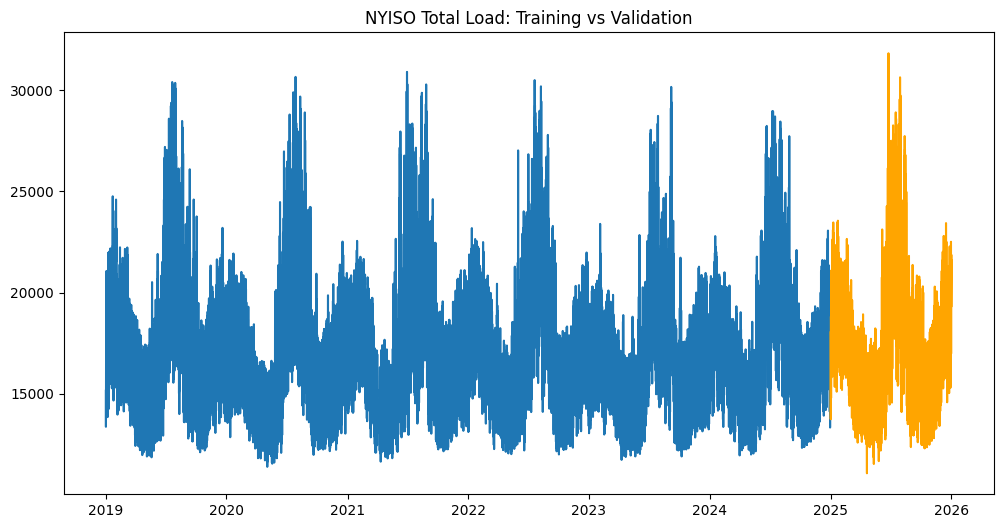

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(train_df.index, train_df['NYISO_Total'], label='Training Data (2019-2024)')
plt.plot(val_df.index, val_df['NYISO_Total'], label='Validation Data (2025)', color='orange')
plt.title('NYISO Total Load: Training vs Validation')

#### Data Standardization

In [13]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()


In [14]:
# FIT the scaler on the training data and TRANSFORM both training and validation sets
train_standard = scalar.fit_transform(train_df[['NYISO_Total']])
val_standard = scalar.transform(val_df[['NYISO_Total']])

In [15]:
joblib.dump(scalar, base_dir / 'scaler.joblib')

['E:\\NYISO_Project\\dataset\\scaler.joblib']

In [16]:
print(type(train_standard))
print(train_standard.shape)
print(type(val_standard))
print(val_standard.shape)

<class 'numpy.ndarray'>
(52603, 1)
<class 'numpy.ndarray'>
(8760, 1)


In [17]:
train_standard[50,0]

np.float64(-0.8452212705350246)

##### Converting the 1D numpy array to 3D tensor

In [18]:
# Function for data window
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i, 0])  # Last 24 hours as features
        y.append(data[i, 0])              # Next hour as target
    X = np.array(X)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))  # Reshape for LSTM input
    y = np.array(y)
    return X, y

In [19]:
look_back = 24
X_train, y_train = create_sequences(train_standard, look_back)
X_val, y_val = create_sequences(val_standard, look_back)

In [20]:
print(f"Feature shape (samples, timesteps, features): {X_train.shape}")
print(f"Target shape (samples,): {y_train.shape}")
print(f"Feature shape (samples, timesteps, features): {X_val.shape}")
print(f"Target shape (samples,): {y_val.shape}")

Feature shape (samples, timesteps, features): (52579, 24, 1)
Target shape (samples,): (52579,)
Feature shape (samples, timesteps, features): (8736, 24, 1)
Target shape (samples,): (8736,)


In [21]:
# saving the preprocessed data for later use
np.save(base_dir / 'X_train.npy', X_train)
np.save(base_dir / 'y_train.npy', y_train)
np.save(base_dir / 'X_val.npy', X_val)
np.save(base_dir / 'y_val.npy', y_val)